<a href="https://colab.research.google.com/github/fcaballerodata/data-analysis-python-guide/blob/main/CasoRFM_Segmentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CASO 2: SEGMENTACIÓN RFM DE CLIENTES BANCARIOS

📊 Dataset de Transacciones:
   Clientes únicos : 499
   Transacciones   : 3,000
   Período         : 2023-01-01 → 2024-12-30
   Monto promedio  : $631.95

📋 Primeras filas:


,cliente_id,fecha,monto,tipo
0,103,2023-08-29,435.61,Compra
1,436,2024-03-20,537.86,Retiro
2,349,2023-10-25,2338.40,Pago
3,271,2023-02-05,75.88,Compra
4,107,2023-03-25,988.65,Compra
5,72,2024-03-27,388.96,Compra
6,189,2024-01-20,304.82,Compra
7,21,2023-06-21,276.03,Transferencia


PASO 1: CALCULAR MÉTRICAS RFM

📅 Fecha de referencia: 2024-12-31

📊 Métricas RFM calculadas:
   Clientes procesados: 499


,cliente_id,Recency,Frequency,Monetary
count,499.00,499.00,499.00,499.00
mean,250.51,116.36,6.01,3799.28
std,144.63,115.30,2.55,3556.83
min,1.00,1.00,1.00,135.48
25%,125.50,38.50,4.00,1858.32
50%,251.00,76.00,6.00,2792.51
75%,375.50,153.00,8.00,4066.85
max,500.00,637.00,15.00,32760.68



📋 Primeros 10 clientes:


...


💡 HALLAZGOS CLAVE:
   • Segmento top por revenue : Loyal Customers
   • % del revenue total      : 28.3%
   • Clientes hibernando      : 96
     (sin transaccionar ~261 días en promedio)
PASO 5: CLUSTERING K-MEANS (Validación técnica)

¿Por qué K-Means además de los scores?
→ Los scores RFM son reglas de negocio (fáciles de explicar)
→ K-Means es matemáticamente óptimo (valida los segmentos)
→ En entrevistas: mostrar que conoces ambos enfoques

📊 Método del Codo para K óptimo:

✅ K seleccionado: 4 clusters

📊 Perfil Clusters K-Means:


,Clientes,Recency_Avg,Freq_Avg,Money_Avg
Cluster_KMeans,,,,
2,42,93.2,7.6,13443.9
0,174,72.4,8.5,3990.4
1,210,80.3,4.4,2299.8
3,73,338.2,3.8,2108.3



📋 Etiquetas de Clusters:


,Clientes,Etiqueta
Cluster_KMeans,,
2,42,⚠️ High Value - Dormant
0,174,🔄 Regular - Medium Value
1,210,😴 Low Engagement
3,73,😴 Low Engagement


PASO 6: VISUALIZACIONES


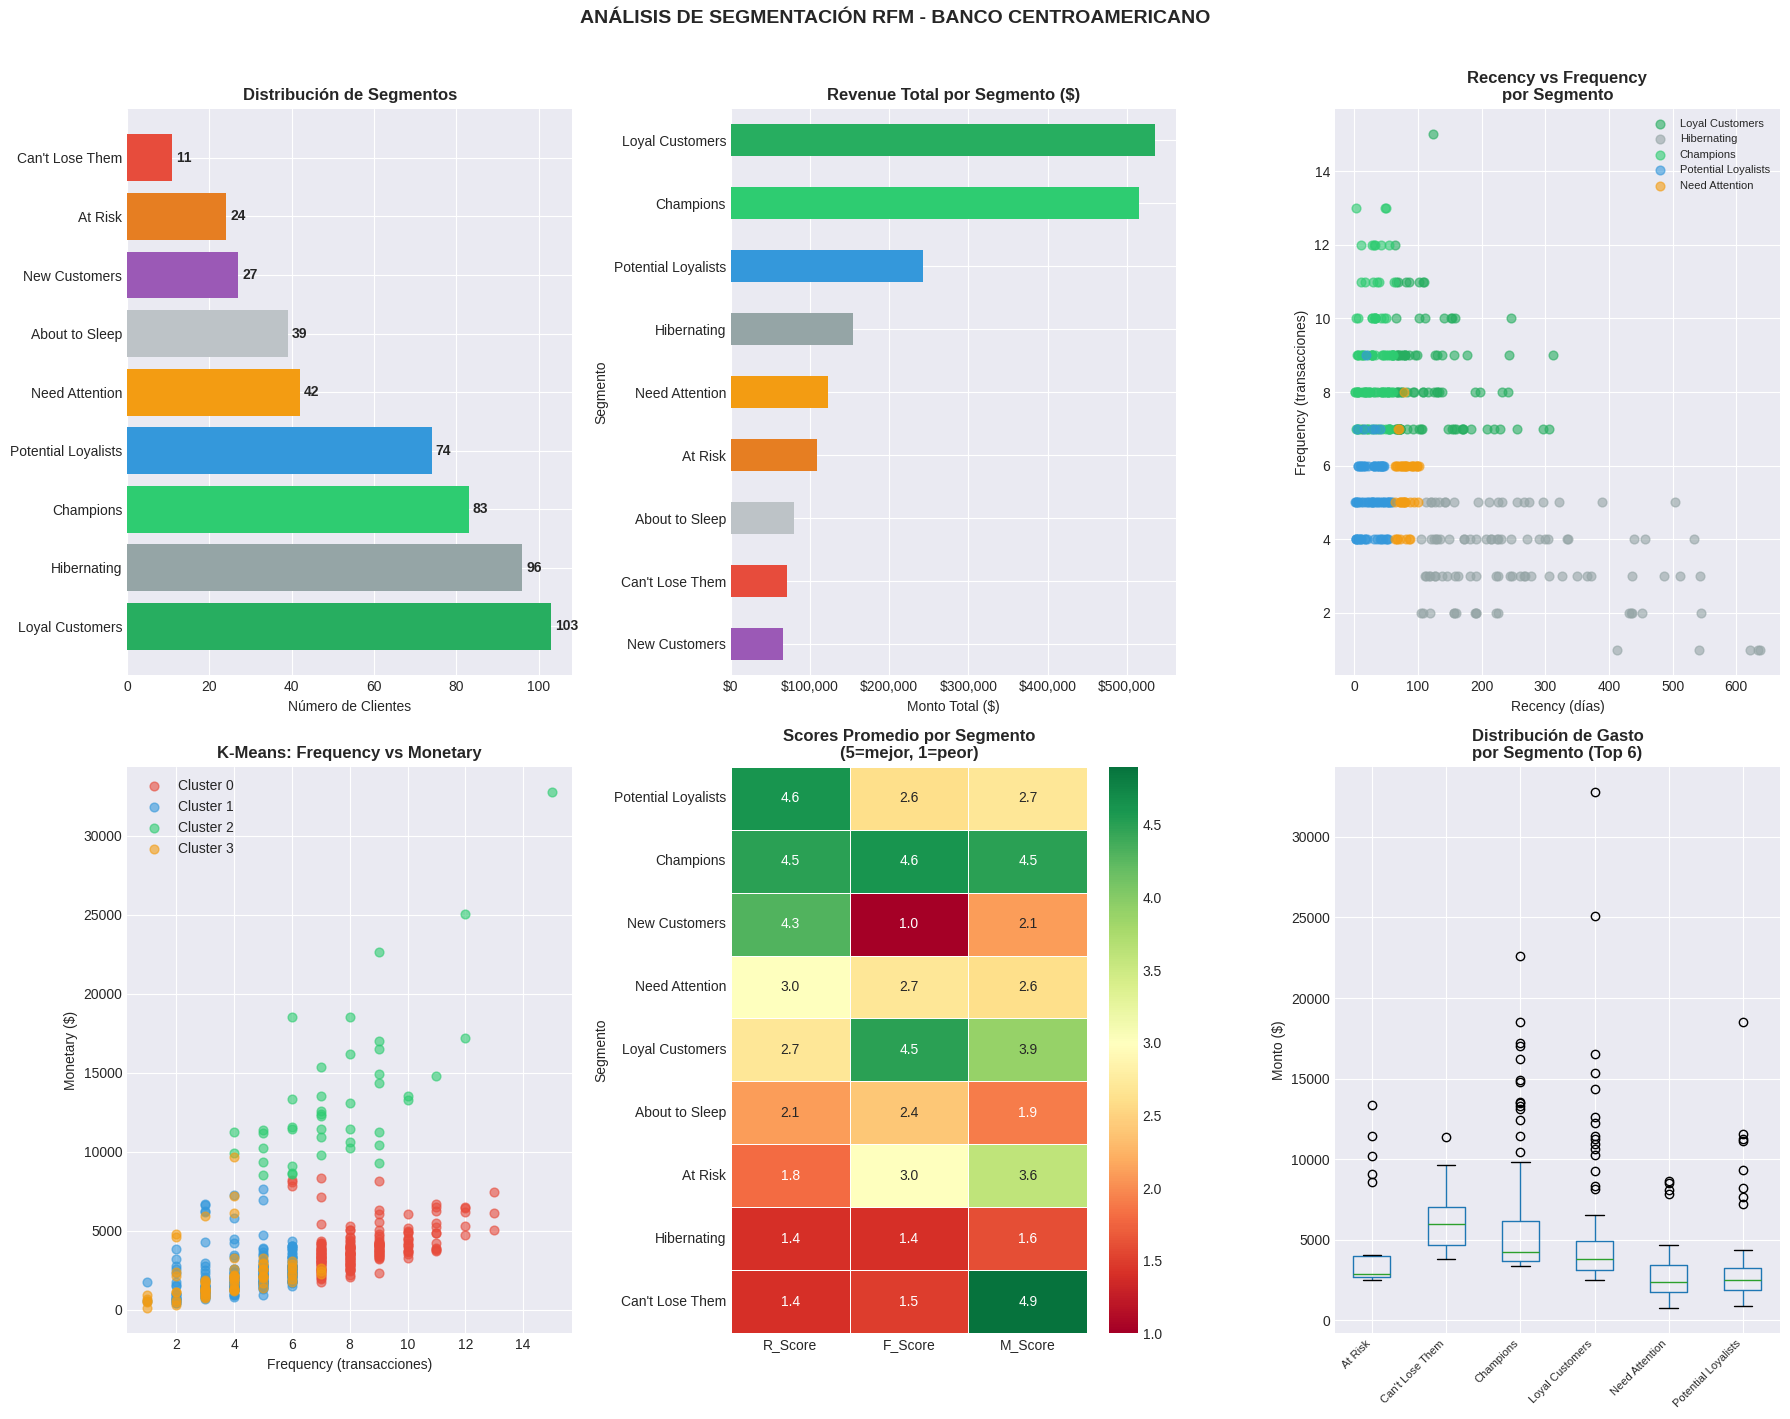


✅ Visualizaciones completadas
PASO 7: ESTRATEGIAS DE NEGOCIO POR SEGMENTO

🏆 CHAMPIONS
   Clientes: 83 | Revenue: $515,589
   Perfil: Compraron recientemente, frecuentemente, y gastan más
   Objetivo: Retención y evangelización (referidos)
   Acciones:
     • Ofrecer programa de recompensas exclusivo
     • Invitar a beta-testing de nuevos productos
     • Asignar ejecutivo de cuenta dedicado
     • Tarjeta de crédito con límite premium

💚 LOYAL CUSTOMERS
   Clientes: 103 | Revenue: $535,660
   Perfil: Compran regularmente. Responden a promociones
   Objetivo: Aumentar valor de cartera (upsell)
   Acciones:
     • Upsell a cuenta premium o seguro complementario
     • Programa de lealtad con puntos
     • Invitar a eventos exclusivos del banco
     • Oferta de crédito pre-aprobado

⚠️ AT RISK
   Clientes: 24 | Revenue: $108,696
   Perfil: Buenos clientes que no transaccionan desde hace tiempo
   Objetivo: Retención - evitar churn
   Acciones:
     • Campaña de reactivación urgente (em

In [1]:
# ============================================================
# CASO 2: SEGMENTACIÓN RFM DE CLIENTES
# ============================================================
# Objetivo: Segmentar clientes usando:
#   - Recency   → ¿Hace cuánto fue su última transacción?
#   - Frequency → ¿Cuántas veces transaccionó?
#   - Monetary  → ¿Cuánto dinero movió en total?
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELDA 1: IMPORTS Y DATOS
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("=" * 60)
print("CASO 2: SEGMENTACIÓN RFM DE CLIENTES")
print("=" * 60)

# ── Crear dataset de transacciones bancarias simulado ──────
np.random.seed(42)

n_clientes   = 500
n_transac    = 3000
fecha_inicio = datetime(2023, 1, 1)
fecha_fin    = datetime(2024, 12, 31)

# Generar transacciones aleatorias
dias_totales = (fecha_fin - fecha_inicio).days

transacciones = pd.DataFrame({
    'cliente_id': np.random.randint(1, n_clientes + 1, n_transac),
    'fecha'     : [fecha_inicio + timedelta(days=int(d))
                   for d in np.random.randint(0, dias_totales, n_transac)],
    'monto'     : np.random.gamma(shape=3, scale=150, size=n_transac).round(2),
    'tipo'      : np.random.choice(['Compra', 'Transferencia', 'Pago', 'Retiro'],
                                    n_transac, p=[0.45, 0.25, 0.20, 0.10])
})

# Hacer que algunos clientes sean más activos (Champions)
clientes_premium = np.random.choice(range(1, n_clientes + 1), 80, replace=False)
mask_premium     = transacciones['cliente_id'].isin(clientes_premium)
transacciones.loc[mask_premium, 'monto'] *= np.random.uniform(2, 5,
                                             mask_premium.sum())

print(f"\n📊 Dataset de Transacciones:")
print(f"   Clientes únicos : {transacciones['cliente_id'].nunique()}")
print(f"   Transacciones   : {len(transacciones):,}")
print(f"   Período         : {transacciones['fecha'].min().date()} → "
      f"{transacciones['fecha'].max().date()}")
print(f"   Monto promedio  : ${transacciones['monto'].mean():,.2f}")

print("\n📋 Primeras filas:")
display(transacciones.head(8))


# ─────────────────────────────────────────────────────────────
# CELDA 2: CALCULAR MÉTRICAS RFM
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 1: CALCULAR MÉTRICAS RFM")
print("=" * 60)

# Fecha de referencia = día siguiente al último registro
fecha_referencia = transacciones['fecha'].max() + timedelta(days=1)
print(f"\n📅 Fecha de referencia: {fecha_referencia.date()}")

# ── Calcular R, F, M por cliente ──────────────────────────
rfm = transacciones.groupby('cliente_id').agg(
    Recency   = ('fecha',  lambda x: (fecha_referencia - x.max()).days),
    Frequency = ('fecha',  'count'),
    Monetary  = ('monto',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("\n📊 Métricas RFM calculadas:")
print(f"   Clientes procesados: {len(rfm)}")
display(rfm.describe().round(2))

print("\n📋 Primeros 10 clientes:")
display(rfm.head(10))

# ── Interpretación de cada métrica ────────────────────────
print("\n💡 INTERPRETACIÓN:")
print(f"   Recency promedio  : {rfm['Recency'].mean():.0f} días sin transaccionar")
print(f"   Frequency promedio: {rfm['Frequency'].mean():.1f} transacciones por cliente")
print(f"   Monetary promedio : ${rfm['Monetary'].mean():,.2f} por cliente")


# ─────────────────────────────────────────────────────────────
# CELDA 3: CALCULAR SCORES RFM (1-5)
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 2: ASIGNAR SCORES 1-5 A CADA MÉTRICA")
print("=" * 60)

print("""
LÓGICA DE SCORES:
─────────────────
Recency   → Menor = MEJOR  (transaccionó hace poco)
            Score 5 = muy reciente, Score 1 = hace mucho

Frequency → Mayor = MEJOR  (transacciona seguido)
            Score 5 = muy frecuente, Score 1 = poco frecuente

Monetary  → Mayor = MEJOR  (mueve mucho dinero)
            Score 5 = gasta mucho, Score 1 = gasta poco
""")

# Recency: invertido (menor días = score mayor)
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]   # ← Invertido: menos días = score 5
).astype(int)

# Frequency: directo (más transacciones = score mayor)
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary: directo (más dinero = score mayor)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Score RFM combinado
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("📊 Distribución de Scores:")
print(f"\nR_Score (Recency):")
print(rfm['R_Score'].value_counts().sort_index())
print(f"\nF_Score (Frequency):")
print(rfm['F_Score'].value_counts().sort_index())
print(f"\nM_Score (Monetary):")
print(rfm['M_Score'].value_counts().sort_index())
print(f"\nRFM_Score total (mín={rfm['RFM_Score'].min()}, "
      f"máx={rfm['RFM_Score'].max()}):")
print(rfm['RFM_Score'].describe().round(2))


# ─────────────────────────────────────────────────────────────
# CELDA 4: SEGMENTAR CLIENTES
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 3: ASIGNAR SEGMENTOS POR SCORE RFM")
print("=" * 60)

def asignar_segmento(row):
    """
    Reglas de negocio para asignar segmento.
    Basado en R_Score, F_Score, M_Score individuales.
    """
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    score   = row['RFM_Score']

    # Champions: Compran seguido, recientemente, y gastan mucho
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Loyal Customers: Compran seguido y gastan bien
    elif f >= 4 and m >= 3:
        return 'Loyal Customers'

    # Potential Loyalists: Recientes con frecuencia media
    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

    # At Risk: Antes compraban bien, ahora no
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'

    # Can't Lose Them: Compraban mucho pero desaparecieron
    elif r <= 2 and m >= 4:
        return "Can't Lose Them"

    # Hibernating: No transaccionan hace mucho
    elif r <= 2 and f <= 2:
        return 'Hibernating'

    # Need Attention: Recencia y frecuencia medias
    elif r >= 3 and f >= 2:
        return 'Need Attention'

    # New Customers: Recientes pero poca frecuencia
    elif r >= 4 and f == 1:
        return 'New Customers'

    else:
        return 'About to Sleep'

rfm['Segmento'] = rfm.apply(asignar_segmento, axis=1)

print("\n📊 Distribución de Segmentos:")
segment_dist = rfm['Segmento'].value_counts()
segment_pct  = (rfm['Segmento'].value_counts(normalize=True) * 100).round(1)

for seg in segment_dist.index:
    count = segment_dist[seg]
    pct   = segment_pct[seg]
    bar   = '█' * int(pct / 2)
    print(f"  {seg:<22} {count:>4} clientes ({pct:>5.1f}%) {bar}")


# ─────────────────────────────────────────────────────────────
# CELDA 5: ANÁLISIS POR SEGMENTO
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 4: PERFIL DE CADA SEGMENTO")
print("=" * 60)

perfil = rfm.groupby('Segmento').agg(
    Clientes        = ('cliente_id', 'count'),
    Recency_Avg     = ('Recency',   'mean'),
    Frequency_Avg   = ('Frequency', 'mean'),
    Monetary_Avg    = ('Monetary',  'mean'),
    Monetary_Total  = ('Monetary',  'sum'),
    RFM_Score_Avg   = ('RFM_Score', 'mean')
).round(1)

perfil['Revenue_Pct'] = (perfil['Monetary_Total'] /
                          perfil['Monetary_Total'].sum() * 100).round(1)

perfil = perfil.sort_values('Monetary_Total', ascending=False)

print("\n")
display(perfil)

print("\n💡 HALLAZGOS CLAVE:")
top_seg = perfil.index[0]
print(f"   • Segmento top por revenue : {top_seg}")
print(f"   • % del revenue total      : {perfil.loc[top_seg, 'Revenue_Pct']}%")

hibernating = 'Hibernating'
if hibernating in perfil.index:
    print(f"   • Clientes hibernando      : {perfil.loc[hibernating, 'Clientes']:.0f}")
    print(f"     (sin transaccionar ~{perfil.loc[hibernating, 'Recency_Avg']:.0f} días en promedio)")


# ─────────────────────────────────────────────────────────────
# CELDA 6: CLUSTERING K-MEANS (VALIDACIÓN)
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 5: CLUSTERING K-MEANS (Validación técnica)")
print("=" * 60)

print("""
¿Por qué K-Means además de los scores?
→ Los scores RFM son reglas de negocio (fáciles de explicar)
→ K-Means es matemáticamente óptimo (valida los segmentos)
→ En entrevistas: mostrar que conoces ambos enfoques
""")

# Preparar features para clustering
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Escalar (OBLIGATORIO para K-Means)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Método del Codo para encontrar K óptimo
print("📊 Método del Codo para K óptimo:\n")
inertias = []
K_range  = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Elegir K=4 (balance entre interpretabilidad y granularidad)
K_OPTIMO = 4
kmeans   = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

print(f"✅ K seleccionado: {K_OPTIMO} clusters")

# Perfil de clusters
cluster_perfil = rfm.groupby('Cluster_KMeans').agg(
    Clientes    = ('cliente_id', 'count'),
    Recency_Avg = ('Recency',    'mean'),
    Freq_Avg    = ('Frequency',  'mean'),
    Money_Avg   = ('Monetary',   'mean')
).round(1).sort_values('Money_Avg', ascending=False)

print("\n📊 Perfil Clusters K-Means:")
display(cluster_perfil)

# Etiquetas descriptivas por cluster
def etiquetar_cluster(row):
    if row['Money_Avg'] > rfm['Monetary'].quantile(0.75):
        if row['Recency_Avg'] < rfm['Recency'].quantile(0.25):
            return '🏆 High Value - Active'
        else:
            return '⚠️  High Value - Dormant'
    elif row['Freq_Avg'] > rfm['Frequency'].median():
        return '🔄 Regular - Medium Value'
    else:
        return '😴 Low Engagement'

cluster_perfil['Etiqueta'] = cluster_perfil.apply(etiquetar_cluster, axis=1)
print("\n📋 Etiquetas de Clusters:")
display(cluster_perfil[['Clientes', 'Etiqueta']])


# ─────────────────────────────────────────────────────────────
# CELDA 7: VISUALIZACIONES
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 6: VISUALIZACIONES")
print("=" * 60)

# Colores por segmento
colores_seg = {
    'Champions'         : '#2ecc71',
    'Loyal Customers'   : '#27ae60',
    'Potential Loyalists': '#3498db',
    'Need Attention'    : '#f39c12',
    'At Risk'           : '#e67e22',
    "Can't Lose Them"   : '#e74c3c',
    'Hibernating'       : '#95a5a6',
    'New Customers'     : '#9b59b6',
    'About to Sleep'    : '#bdc3c7'
}

fig = plt.figure(figsize=(18, 14))

# ── Plot 1: Distribución de segmentos ──────────────────────
ax1 = plt.subplot(2, 3, 1)
seg_counts = rfm['Segmento'].value_counts()
colors_list = [colores_seg.get(s, '#7f8c8d') for s in seg_counts.index]
bars = ax1.barh(seg_counts.index, seg_counts.values, color=colors_list)
ax1.set_title('Distribución de Segmentos', fontweight='bold', fontsize=12)
ax1.set_xlabel('Número de Clientes')
for bar, val in zip(bars, seg_counts.values):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontweight='bold')

# ── Plot 2: Revenue por segmento ───────────────────────────
ax2 = plt.subplot(2, 3, 2)
revenue_seg = rfm.groupby('Segmento')['Monetary'].sum().sort_values(ascending=True)
colors_rev  = [colores_seg.get(s, '#7f8c8d') for s in revenue_seg.index]
revenue_seg.plot(kind='barh', ax=ax2, color=colors_rev)
ax2.set_title('Revenue Total por Segmento ($)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Monto Total ($)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# ── Plot 3: Scatter R vs F (color=segmento) ────────────────
ax3 = plt.subplot(2, 3, 3)
top_segs = rfm['Segmento'].value_counts().head(5).index
for seg in top_segs:
    mask = rfm['Segmento'] == seg
    ax3.scatter(rfm.loc[mask, 'Recency'],
                rfm.loc[mask, 'Frequency'],
                label=seg,
                alpha=0.6,
                color=colores_seg.get(seg, '#7f8c8d'),
                s=40)
ax3.set_xlabel('Recency (días)')
ax3.set_ylabel('Frequency (transacciones)')
ax3.set_title('Recency vs Frequency\npor Segmento', fontweight='bold', fontsize=12)
ax3.legend(fontsize=8, loc='upper right')

# ── Plot 4: Scatter F vs M (K-Means clusters) ──────────────
ax4 = plt.subplot(2, 3, 4)
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for cluster in range(K_OPTIMO):
    mask = rfm['Cluster_KMeans'] == cluster
    ax4.scatter(rfm.loc[mask, 'Frequency'],
                rfm.loc[mask, 'Monetary'],
                label=f'Cluster {cluster}',
                alpha=0.6,
                color=cluster_colors[cluster],
                s=40)
ax4.set_xlabel('Frequency (transacciones)')
ax4.set_ylabel('Monetary ($)')
ax4.set_title('K-Means: Frequency vs Monetary', fontweight='bold', fontsize=12)
ax4.legend()

# ── Plot 5: Heatmap RFM scores por segmento ────────────────
ax5 = plt.subplot(2, 3, 5)
heatmap_data = rfm.groupby('Segmento')[['R_Score', 'F_Score', 'M_Score']].mean().round(1)
heatmap_data = heatmap_data.sort_values('R_Score', ascending=False)
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=3,
            ax=ax5, fmt='.1f', linewidths=0.5)
ax5.set_title('Scores Promedio por Segmento\n(5=mejor, 1=peor)',
              fontweight='bold', fontsize=12)

# ── Plot 6: Boxplot Monetary por segmento ──────────────────
ax6 = plt.subplot(2, 3, 6)
seg_order = rfm.groupby('Segmento')['Monetary'].median().sort_values(
    ascending=False).index.tolist()
rfm_plot  = rfm[rfm['Segmento'].isin(seg_order[:6])]
rfm_plot.boxplot(column='Monetary', by='Segmento', ax=ax6)
ax6.set_title('Distribución de Gasto\npor Segmento (Top 6)',
              fontweight='bold', fontsize=12)
ax6.set_xlabel('')
ax6.set_ylabel('Monto ($)')
plt.sca(ax6)
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.suptitle('ANÁLISIS DE SEGMENTACIÓN RFM - BANCO CENTROAMERICANO',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones completadas")


# ─────────────────────────────────────────────────────────────
# CELDA 8: ESTRATEGIAS POR SEGMENTO
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("PASO 7: ESTRATEGIAS DE NEGOCIO POR SEGMENTO")
print("=" * 60)

estrategias = {
    'Champions': {
        'emoji'    : '🏆',
        'descripcion': 'Compraron recientemente, frecuentemente, y gastan más',
        'acciones' : [
            'Ofrecer programa de recompensas exclusivo',
            'Invitar a beta-testing de nuevos productos',
            'Asignar ejecutivo de cuenta dedicado',
            'Tarjeta de crédito con límite premium'
        ],
        'objetivo' : 'Retención y evangelización (referidos)'
    },
    'Loyal Customers': {
        'emoji'    : '💚',
        'descripcion': 'Compran regularmente. Responden a promociones',
        'acciones' : [
            'Upsell a cuenta premium o seguro complementario',
            'Programa de lealtad con puntos',
            'Invitar a eventos exclusivos del banco',
            'Oferta de crédito pre-aprobado'
        ],
        'objetivo' : 'Aumentar valor de cartera (upsell)'
    },
    'At Risk': {
        'emoji'    : '⚠️',
        'descripcion': 'Buenos clientes que no transaccionan desde hace tiempo',
        'acciones' : [
            'Campaña de reactivación urgente (email + call)',
            'Oferta especial por tiempo limitado',
            'Encuesta: ¿por qué dejaron de usar el banco?',
            'Mejorar experiencia según feedback'
        ],
        'objetivo' : 'Retención - evitar churn'
    },
    "Can't Lose Them": {
        'emoji'    : '🚨',
        'descripcion': 'Alto valor histórico pero inactivos. Riesgo de fuga total',
        'acciones' : [
            'Contacto directo de gerente (no automatizado)',
            'Oferta de beneficio exclusivo personalizado',
            'Revisión de experiencia negativa pasada',
            'Propuesta de migración a producto mejor'
        ],
        'objetivo' : 'Recuperación urgente'
    },
    'Hibernating': {
        'emoji'    : '😴',
        'descripcion': 'Inactivos hace mucho. Bajo valor reciente',
        'acciones' : [
            'Campaña de reactivación de bajo costo (email)',
            'Oferta de producto de entrada (cuenta básica)',
            'Evaluar si vale la pena o cerrar cuenta',
            'Segmentar entre rescatables y no rescatables'
        ],
        'objetivo' : 'Reactivación selectiva'
    },
    'New Customers': {
        'emoji'    : '🌱',
        'descripcion': 'Recientes pero poca frecuencia. Aún explorando',
        'acciones' : [
            'Onboarding digital paso a paso',
            'Primer producto adicional (tarjeta débito premium)',
            'Educación financiera gamificada',
            'Incentivo por segunda transacción'
        ],
        'objetivo' : 'Desarrollo del cliente'
    }
}

for segmento, info in estrategias.items():
    if segmento in rfm['Segmento'].unique():
        n_clientes_seg = (rfm['Segmento'] == segmento).sum()
        rev_seg        = rfm[rfm['Segmento'] == segmento]['Monetary'].sum()

        print(f"\n{info['emoji']} {segmento.upper()}")
        print(f"   Clientes: {n_clientes_seg} | Revenue: ${rev_seg:,.0f}")
        print(f"   Perfil: {info['descripcion']}")
        print(f"   Objetivo: {info['objetivo']}")
        print(f"   Acciones:")
        for accion in info['acciones']:
            print(f"     • {accion}")


# ─────────────────────────────────────────────────────────────
# CELDA 9: FUNCIÓN REUTILIZABLE
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("FUNCIÓN REUTILIZABLE: calcular_rfm()")
print("=" * 60)

def calcular_rfm(df_transacciones,
                 col_cliente='cliente_id',
                 col_fecha='fecha',
                 col_monto='monto',
                 fecha_ref=None):
    """
    Calcula segmentación RFM completa para cualquier dataset.

    Parámetros:
    -----------
    df_transacciones : pd.DataFrame - Dataset con transacciones
    col_cliente      : str          - Nombre columna cliente ID
    col_fecha        : str          - Nombre columna fecha
    col_monto        : str          - Nombre columna monto
    fecha_ref        : datetime     - Fecha de referencia (None = hoy)

    Retorna:
    --------
    pd.DataFrame con columnas RFM, scores y segmento
    """

    df = df_transacciones.copy()
    df[col_fecha] = pd.to_datetime(df[col_fecha])

    if fecha_ref is None:
        fecha_ref = df[col_fecha].max() + timedelta(days=1)

    # Calcular R, F, M
    rfm_result = df.groupby(col_cliente).agg(
        Recency   = (col_fecha,  lambda x: (fecha_ref - x.max()).days),
        Frequency = (col_fecha,  'count'),
        Monetary  = (col_monto,  'sum')
    ).reset_index()

    # Scores 1-5
    rfm_result['R_Score'] = pd.qcut(rfm_result['Recency'].rank(method='first'),
                                     5, labels=[5, 4, 3, 2, 1]).astype(int)
    rfm_result['F_Score'] = pd.qcut(rfm_result['Frequency'].rank(method='first'),
                                     5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm_result['M_Score'] = pd.qcut(rfm_result['Monetary'].rank(method='first'),
                                     5, labels=[1, 2, 3, 4, 5]).astype(int)

    rfm_result['RFM_Score'] = (rfm_result['R_Score'] +
                                rfm_result['F_Score'] +
                                rfm_result['M_Score'])

    # Segmentos
    rfm_result['Segmento'] = rfm_result.apply(asignar_segmento, axis=1)

    return rfm_result


# Demo de la función
print("\n📊 Demo función calcular_rfm():")
rfm_demo = calcular_rfm(transacciones)

print(f"\nResultado: {len(rfm_demo)} clientes segmentados")
print("\nDistribución:")
print(rfm_demo['Segmento'].value_counts())

print("\n✅ CASO 2 COMPLETADO - RFM segmentation lista")
print("=" * 60)